# Phase 9 — Market Regime Detection

Explores the rule-based `regime` column (`backend/app/regime/detector.py`) computed on top of
`data/features/`: distribution across all 12 (asset × timeframe) combinations, a regime
timeline for one series, and a comparison against the exploratory KMeans clustering
alternative (spec Section 6: "consider an unsupervised approach such as clustering if
appropriate" — implemented, but explicitly *not* used as the live per-bar feature; see
`cluster_regimes_exploratory`'s docstring for why).

**Scope reminder**: historical data only, not a live system. See the project root `README.md`.

In [1]:
import glob
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "backend"))
from app.config import ASSETS  # noqa: E402
from app.regime.detector import cluster_regimes_exploratory  # noqa: E402

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "data" / "features"

ASSET_KEYS = list(ASSETS.keys())
TIMEFRAMES = ["M15", "H1", "H4", "D1"]
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4)


def latest_with_regime(asset_key: str, timeframe: str):
    manifests = sorted(FEATURES_DIR.glob(f"{asset_key}_{timeframe}_*.manifest.json"))
    for m in reversed(manifests):
        manifest = json.loads(m.read_text())
        if manifest.get("includes_regime"):
            parquet_path = m.with_suffix("").with_suffix(".parquet")
            return pd.read_parquet(parquet_path), manifest
    return None, None


datasets, manifests = {}, {}
for asset_key in ASSET_KEYS:
    for tf in TIMEFRAMES:
        df, manifest = latest_with_regime(asset_key, tf)
        if df is not None:
            datasets[(asset_key, tf)] = df
            manifests[(asset_key, tf)] = manifest

print(f"Loaded {len(datasets)} / {len(ASSET_KEYS) * len(TIMEFRAMES)} regime-labeled datasets")

Loaded 12 / 12 regime-labeled datasets


## Regime distribution across all 12 combinations

In [2]:
rows = []
for (asset_key, tf), manifest in manifests.items():
    pct = manifest["regime_distribution"]["percentages"]
    rows.append({"asset": asset_key, "timeframe": tf, **pct})
dist_df = pd.DataFrame(rows).set_index(["asset", "timeframe"]).sort_index()
dist_df

Sideways / Range-Bound  Low Volatility  High Volatility  Bullish Trending  Bearish Trending
asset  timeframe                                                                                             
BTCUSD D1                          43.46           27.33            21.42              6.29              1.51
       H1                          47.08           26.60            21.75              2.78              1.80
       H4                          51.48           23.71            20.18              3.35              1.28
       M15                         52.07           23.26            20.67              2.45              1.56
EURUSD D1                          43.61           31.50            22.24              1.75              0.90
       H1                          52.74           21.59            19.33              3.46              2.88
       H4                          51.00           24.89            18.97              3.06              2.08
       M15                         57.42           19.26            16.57              4.24              2.51
XAUUSD D1                          45.86           25.60            20.65              6.03              1.86
       H1                          49.27           26.38            19.09              3.92              1.33
       H4                          43.46           28.03            24.33              4.01              0.17
       M15                         57.27           19.16            19.00              2.83              1.74

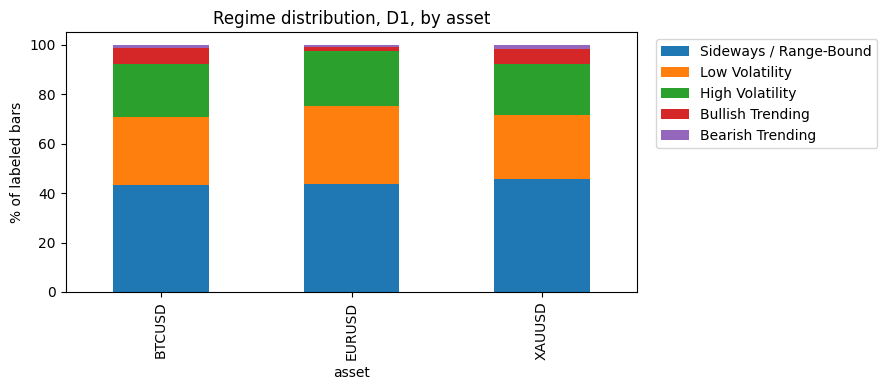

In [3]:
d1_dist = dist_df.xs("D1", level="timeframe")
d1_dist.plot(kind="bar", stacked=True, figsize=(9, 4), title="Regime distribution, D1, by asset")
plt.ylabel("% of labeled bars")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Regime timeline — EUR/USD D1

Close price colored by detected regime, most recent ~2 years, so individual regime segments
are visually distinguishable.

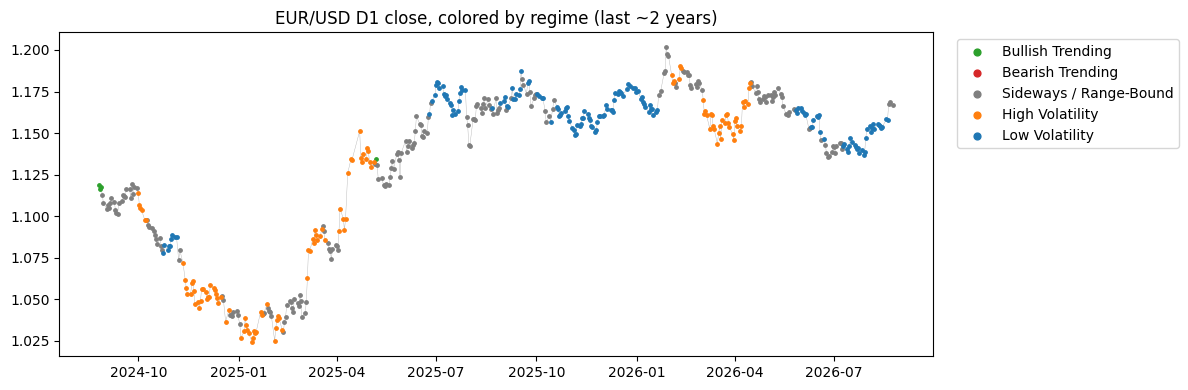

In [4]:
df = datasets[("EURUSD", "D1")].dropna(subset=["regime"])
df = df[df.index >= df.index.max() - pd.Timedelta(days=730)]

colors = {
    "Bullish Trending": "#2ca02c",
    "Bearish Trending": "#d62728",
    "Sideways / Range-Bound": "#7f7f7f",
    "High Volatility": "#ff7f0e",
    "Low Volatility": "#1f77b4",
}
fig, ax = plt.subplots(figsize=(12, 4))
for label, color in colors.items():
    mask = df["regime"] == label
    ax.scatter(df.index[mask], df["close"][mask], s=6, color=color, label=label)
ax.plot(df.index, df["close"], color="black", linewidth=0.3, alpha=0.3, zorder=0)
ax.set_title("EUR/USD D1 close, colored by regime (last ~2 years)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=2)
plt.tight_layout()
plt.show()

## Clustering comparison (exploratory only — see docstring on why this isn't the live feature)

Runs `cluster_regimes_exploratory` (KMeans, fit on the *entire* series — not causal, not used
by any model) on the same EUR/USD D1 data and cross-tabulates cluster assignment against the
rule-based `regime` label, to see whether the two independent approaches broadly agree.

In [5]:
full_df = datasets[("EURUSD", "D1")].copy()
clusters = cluster_regimes_exploratory(full_df, n_clusters=5)
full_df["cluster"] = clusters

crosstab = pd.crosstab(full_df["cluster"], full_df["regime"])
crosstab

regime,Bearish Trending,Bullish Trending,High Volatility,Low Volatility,Sideways / Range-Bound
cluster,,,,,
0,0,0,150,189,711
1,0,11,454,0,336
2,27,0,610,4,202
3,0,88,1,799,562
4,24,0,43,717,642


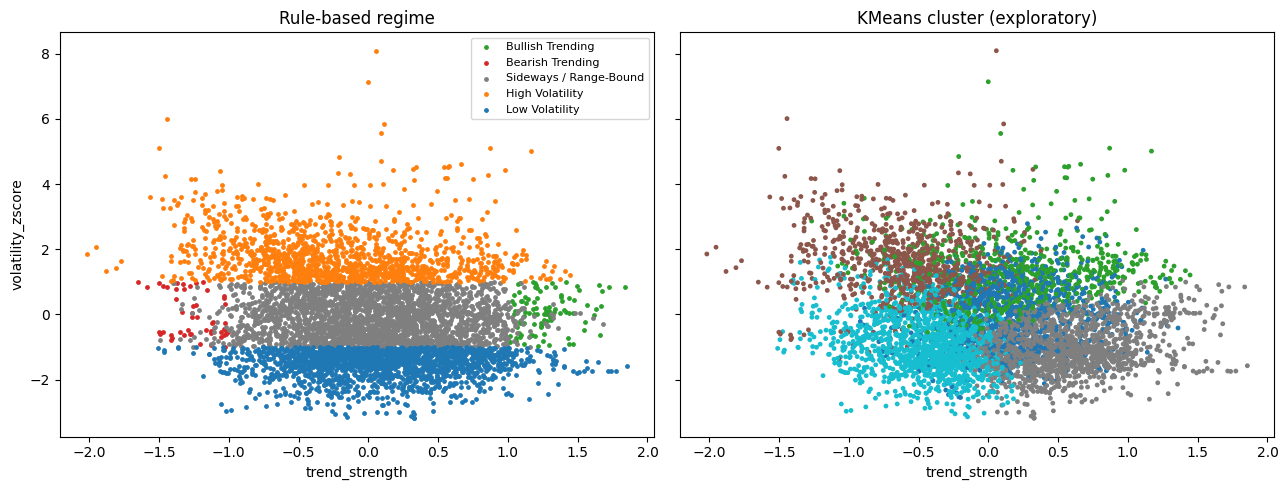

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

plot_df = full_df.dropna(subset=["trend_strength", "volatility_zscore", "regime"])
for label, color in colors.items():
    mask = plot_df["regime"] == label
    axes[0].scatter(plot_df["trend_strength"][mask], plot_df["volatility_zscore"][mask], s=6, color=color, label=label)
axes[0].set_title("Rule-based regime")
axes[0].set_xlabel("trend_strength")
axes[0].set_ylabel("volatility_zscore")
axes[0].legend(fontsize=8)

cluster_df = full_df.dropna(subset=["trend_strength", "volatility_zscore", "cluster"])
sc = axes[1].scatter(
    cluster_df["trend_strength"], cluster_df["volatility_zscore"], s=6, c=cluster_df["cluster"].astype(int), cmap="tab10"
)
axes[1].set_title("KMeans cluster (exploratory)")
axes[1].set_xlabel("trend_strength")
plt.tight_layout()
plt.show()

## Summary of findings

1. **Sideways/Range-Bound dominates** across all 12 combinations (43-57% of labeled bars) —
   the rule requires *both* a strong trend-strength move *and* full EMA20>EMA50>EMA200 (or
   reverse) alignment to call a trend, a deliberately strict bar that classifies most
   "somewhat trending" periods as Sideways rather than a weak trend. Worth revisiting the
   `REGIME.trend_strength_threshold` if a future phase wants trending regimes to be less rare.
2. **Volatility extremes (High + Low combined) run 35-45%** of labeled bars — broadly
   consistent with a roughly-normal-ish, slightly fat-tailed distribution of a rolling
   z-score with +-1 cutoffs (a symmetric normal distribution would give ~32% by construction).
3. **Trending regimes are genuinely rare** (Bullish + Bearish combined: 1-8% depending on
   asset/timeframe) — a direct, visible consequence of point 1's strict criteria.
4. **The exploratory KMeans clusters correlate with, but don't cleanly reproduce, the
   rule-based regimes** (see the crosstab and side-by-side scatter above) — expected, since
   KMeans optimizes for geometric cluster compactness in feature space, not for matching a
   human-interpretable trend/volatility taxonomy. This is exactly why the rule-based approach
   was chosen as the live, causal feature (see `detector.py`'s module docstring) while
   clustering stays a retrospective comparison tool.

**Next (Phase 10):** FinBERT news sentiment, timestamp-aware, joined onto this same
`data/features/` schema the same way regime was.